## Dataset Information

The objective of this task is to detect hate speech in tweets.

For the sake of simplicity, we say a tweet contains hate speech if it has a racist or sexist sentiment associated with it.

Label '1' denotes the tweet is racist/sexist and label '0' denotes the tweet is not racist/sexist. Your objective is to predict the labels on the test dataset.

## Import modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # Used for regular expression operations, typically for text cleaning.
import string
import nltk # Natural Language Toolkit, used for working with human language data.
from nltk.stem.porter import PorterStemmer # Used for stemming words (reducing words to their root form).
from sklearn.feature_extraction.text import CountVectorizer # Used to convert text data into a matrix of token counts.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

## Load and prepare the dataset

In [2]:
df = pd.read_csv('Twitter Sentiments.csv')
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [3]:
df.info()
# >> Note: tweet is object type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [4]:
def remove_pattern(text, pattern):
    r = re.findall(pattern, text)
    for i in r:
        text = re.sub(i, '', text)
    return text

# Remove mentions, special characters, numbers and punctuations
df['clean_tweet'] = np.vectorize(remove_pattern)(df['tweet'], r"@[\w]*") # turn remove_pattern() into a vectorized function
df['clean_tweet'] = df['clean_tweet'].str.replace("[^a-zA-Z#]", " ")
df.head()

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can't use cause th...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation,factsguide: society now #motivation


In [5]:
df['clean_tweet'] = df['clean_tweet'].apply(lambda x: " ".join([word for word in x.split() if len(word) >= 3]))
df.head()

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,when father dysfunctional and selfish drags hi...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit can't use cause they d...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,#model love take with all the time urð±!!! ð...
4,5,0,factsguide: society now #motivation,factsguide: society now #motivation


In [6]:
# Tokenize the tweets
tokens = df['clean_tweet'].apply(lambda x: x.split())

# Stem the words
stemmer = PorterStemmer()
tokens = tokens.apply(lambda x: [stemmer.stem(word) for word in x])
tokens.head()


,clean_tweet
0,"[when, father, dysfunct, and, selfish, drag, h..."
1,"[thank, for, #lyft, credit, can't, use, caus, ..."
2,"[bihday, your, majesti]"
3,"[#model, love, take, with, all, the, time, urð..."
4,"[factsguide:, societi, now, #motiv]"


In [7]:
# Combine into one sentence
df['clean_tweet'] = tokens.apply(lambda x: " ".join([w for w in x]))
df.head()

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,when father dysfunct and selfish drag hi kid i...
1,2,0,@user @user thanks for #lyft credit i can't us...,thank for #lyft credit can't use caus they don...
2,3,0,bihday your majesty,bihday your majesti
3,4,0,#model i love u take with u all the time in ...,#model love take with all the time urð±!!! ð...
4,5,0,factsguide: society now #motivation,factsguide: societi now #motiv


## EDA

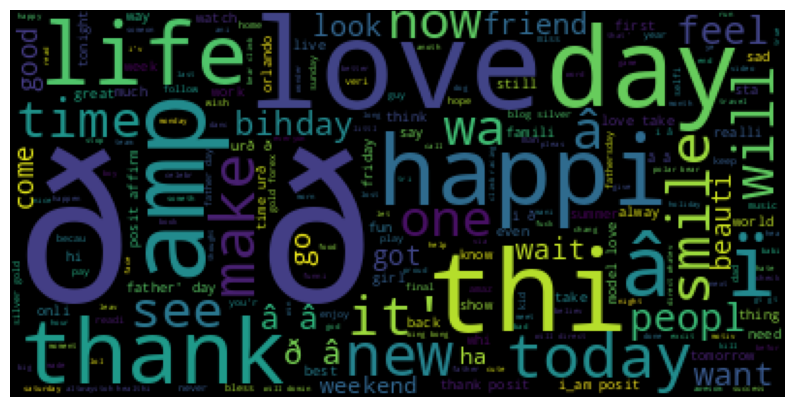

In [8]:
# Positive words
all_pos = " ".join(twt for twt in df['clean_tweet'][df['label'] == 0])

from wordcloud import WordCloud
wcl = WordCloud().generate(all_pos)

plt.figure(figsize=(10, 10))
plt.imshow(wcl)
plt.axis('off')
plt.show()

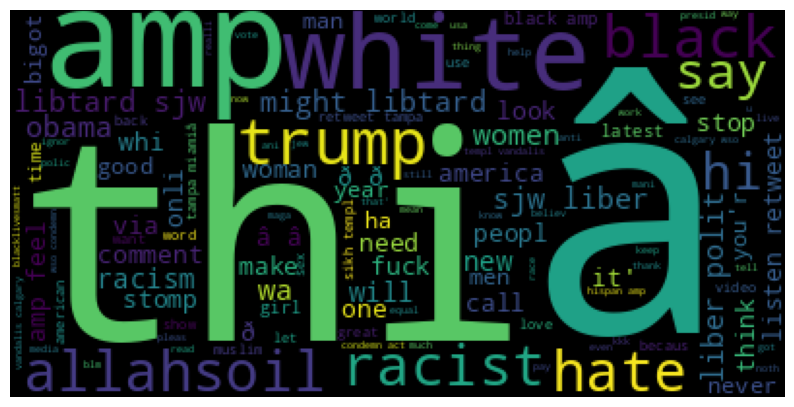

In [9]:
# Negative words
all_neg = " ".join(twt for twt in df['clean_tweet'][df['label'] == 1])

from wordcloud import WordCloud
wcl = WordCloud().generate(all_neg)

plt.figure(figsize=(10, 10))
plt.imshow(wcl)
plt.axis('off')
plt.show()

In [10]:
# Extract hashtags
def hashtag_extract(tweets):
  hashtags = []
  for twt in tweets:
      # for word in twt.split():
      #     if word.startswith('#'):
      #         hashtags.append(word)
      ht = re.findall(r"#(\w+)", twt)
      hashtags.append(ht)
  return hashtags

hashtag_pos = hashtag_extract(df['clean_tweet'][df['label'] == 0])
hashtag_neg = hashtag_extract(df['clean_tweet'][df['label'] == 1])

In [11]:
hashtag_pos[:5]

[['run'], ['lyft', 'disapoint', 'getthank'], [], ['model'], ['motiv']]

In [12]:
hashtag_pos = sum(hashtag_pos, [])
hashtag_neg = sum(hashtag_neg, [])

hashtag_pos[:5]

['run', 'lyft', 'disapoint', 'getthank', 'model']

In [13]:
freq = nltk.FreqDist(hashtag_pos)
df_temp = pd.DataFrame({'Hashtag': list(freq.keys()), 'Count': list(freq.values())})
df_temp.head()

,Hashtag,Count
0,run,70
1,lyft,2
2,disapoint,1
3,getthank,2
4,model,374


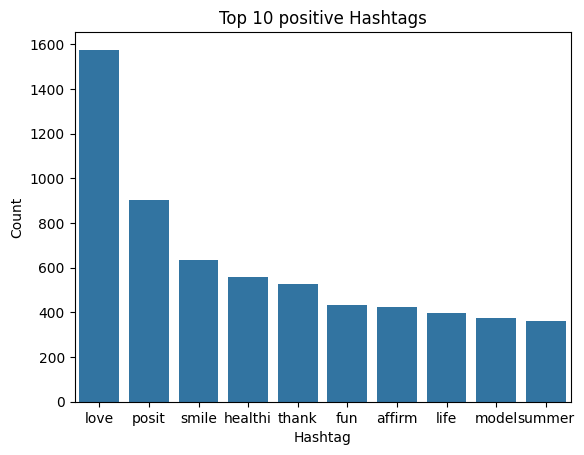

In [14]:
df_temp = df_temp.nlargest(columns='Count', n=10)
sns.barplot(data=df_temp, x='Hashtag', y='Count')
plt.xlabel('Hashtag')
plt.ylabel('Count')
plt.title('Top 10 positive Hashtags')
plt.show()

In [15]:
freq = nltk.FreqDist(hashtag_neg)
df_temp = pd.DataFrame({'Hashtag': list(freq.keys()), 'Count': list(freq.values())})
df_temp.head()

,Hashtag,Count
0,cnn,9
1,michigan,2
2,tcot,14
3,australia,6
4,opkillingbay,2


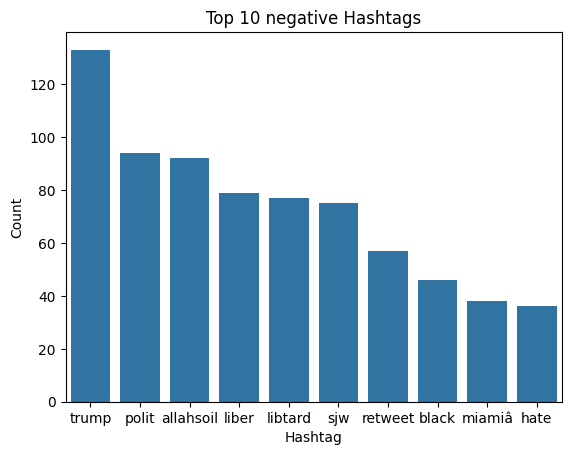

In [16]:
df_temp = df_temp.nlargest(columns='Count', n=10)
sns.barplot(data=df_temp, x='Hashtag', y='Count')
plt.xlabel('Hashtag')
plt.ylabel('Count')
plt.title('Top 10 negative Hashtags')
plt.show()

## Train/Test split and Model creation

In [17]:
# Feature extraction
# BoW
cv = CountVectorizer(max_df=0.9, min_df=2, max_features=1000, stop_words='english') # Ignore words that appear > 90% of tweets or < 2 tweets, and stop words (a, is, in...)
X = cv.fit_transform(df['clean_tweet']) # Takes words and turns them into features
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [18]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Evaluation

In [19]:
y_pred = model.predict(X_test)

print('Accuracy: ', accuracy_score(y_test, y_pred))
print('F1 Score: ', f1_score(y_test, y_pred))

Accuracy:  0.9471269162582125
F1 Score:  0.5082444228903976


In [20]:
# Create a DataFrame to compare actual and predicted labels
results_df = pd.DataFrame({'Actual Label': y_test, 'Predicted Label': y_pred})
results_df = results_df.reset_index(drop=True) # Reset index to align y_test and y_pred if they have different indices

results_df.head()

,Actual Label,Predicted Label
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
